# Proyecto 1 — Predicción de Precios de Oportunidad de la Energía en Guatemala
### Modelos de Regresión, Ingeniería de Variables y Explicabilidad
**Maestría en Data Science — Statistical Learning I**

---

## Índice
1. Carga, limpieza y transformación de datos
2. Análisis exploratorio del mercado
3. Ingeniería de variables
4. Preprocesamiento y modelado
5. Optimización y comparación de modelos
6. Evaluación final sobre 2025
7. Explicabilidad, preguntas obligatorias y conclusión

## 0. Configuración del entorno
Importaciones y utilidades comunes. Las dependencias están en `requirements.txt`.

In [1]:
import warnings
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     TimeSeriesSplit, cross_val_score, validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50, "display.width", 200)

RANDOM_STATE = 42
FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("outputs", exist_ok=True)

def savefig(fig, name):
    """Guarda una figura en outputs/figures con nombre dado."""
    fig.savefig(os.path.join(FIG_DIR, name), dpi=120, bbox_inches="tight")

FILES = {2023: "Precios2023.xls", 2024: "Precios2024.xls", 2025: "Precios2025.xls"}

## 1. Carga, Limpieza y Transformación de Datos

Cada archivo `PreciosX.xls` es un reporte anual del Administrador del Mercado Mayorista (AMM)
con la hoja `POE (Anual)`. La estructura es:

| Fila | Contenido |
|------|-----------|
| 0 | "Administrador del Mercado Mayorista de Guatemala" |
| 1 | "Precios de Oportunidad de la Energía" |
| 2 | "Año XXXX" |
| 3 | Encabezados: Día \| hora \| USD/MWH |
| 4+ | Datos: una fila por combinación (fecha, hora) |


In [2]:
# Inspección de la estructura cruda (primeras filas, sin encabezado)
raw_preview = pd.read_excel(FILES[2023], engine="xlrd", sheet_name="POE (Anual)", header=None, nrows=8)
raw_preview

,0,1,2
0,Administrador del Mercado Mayorista de Guatemala,NaN,NaN
1,Precios de Oportunidad de la Energía,NaN,NaN
2,Año 2023,NaN,NaN
3,Día,hora,USD/MWH
4,2023-01-01 00:00:00,0,74.2314
5,2023-01-01 00:00:00,1,74.2314
6,2023-01-01 00:00:00,2,59.0752
7,2023-01-01 00:00:00,3,59.0752


### 1.1 Funciones de carga y limpieza

Durante la inspección inicial se detectaron tres tipos de problemas de calidad que se corrigen aquí:

1. **Horas mal digitadas** (solo 2023): `220→22`, `230→23`, `2300→23`
2. **Precios con caracteres basura** al final del número (p. ej. `167.9951l`, `69.038.0`, `2.1302.wq`)
3. **Valores extremos imposibles** `>1000` USD/MWh, hasta 1.3 millones

In [3]:
COLUMNS = ["date", "hour", "usd_mwh"]
HEADER_ROW = 3
SHEET = "POE (Anual)"
MAX_PLAUSIBLE_PRICE = 1000.0  # umbral de precio plausible (USD/MWh); ver pregunta 7.7

# Captura el flotante inicial de un texto y descarta basura final ("167.9951l" -> 167.9951)
_LEADING_FLOAT = re.compile(r"^-?\d+(?:\.\d+)?")

def clean_price(value):
    """Convierte un precio a float descartando caracteres basura finales; NaN si no hay dígitos."""
    if isinstance(value, (int, float)):
        return float(value)
    m = _LEADING_FLOAT.match(str(value).strip())
    return float(m.group()) if m else float("nan")

def clean_hour(value):
    """Normaliza la hora al rango 0-23 eliminando ceros finales (220->22, 2300->23)."""
    h = int(value)
    while h > 23:
        h //= 10
    return h

def load_year(path):
    """Carga un archivo anual del AMM y devuelve un DataFrame limpio y tipado (formato largo)."""
    df = pd.read_excel(path, engine="xlrd", sheet_name=SHEET, header=HEADER_ROW)
    df.columns = COLUMNS
    df["date"] = pd.to_datetime(df["date"])
    df["hour"] = df["hour"].map(clean_hour).astype(int)
    df["usd_mwh"] = df["usd_mwh"].map(clean_price).astype(float)
    df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
    df["year"] = df["date"].dt.year
    df = df.sort_values("datetime").reset_index(drop=True)
    return df[["datetime", "date", "year", "hour", "usd_mwh"]]

def flag_extreme_prices(df, threshold=MAX_PLAUSIBLE_PRICE):
    """Marca como NaN los precios > threshold (errores). Agrega columna is_price_error."""
    out = df.copy()
    out["is_price_error"] = out["usd_mwh"].isna() | (out["usd_mwh"] > threshold)
    out.loc[out["usd_mwh"] > threshold, "usd_mwh"] = np.nan
    return out

def data_quality_report(df):
    """Resumen de calidad de datos para documentar las correcciones (Req. 1)."""
    per_day = df.groupby("date").size()
    return {
        "filas": len(df),
        "rango": f"{df.date.min().date()} .. {df.date.max().date()}",
        "duplicados_(fecha,hora)": int(df.duplicated(["date", "hour"]).sum()),
        "precios_faltantes": int(df["usd_mwh"].isna().sum()),
        "horas_fuera_rango": int(((df.hour < 0) | (df.hour > 23)).sum()),
        "dias_sin_24_registros": int((per_day != 24).sum()),
    }

### 1.2 Carga y verificación de calidad

In [ ]:
# Carga con raw data y reporte de calidad por año
raw = {y: load_year(p) for y, p in FILES.items()}
quality_before = pd.DataFrame({y: data_quality_report(df) for y, df in raw.items()}).T
print("Reporte de calidad tras corregir horas y texto (antes de marcar extremos):")
quality_before

Reporte de calidad tras corregir horas y texto (antes de marcar extremos):


,filas,rango,"duplicados_(fecha,hora)",precios_faltantes,horas_fuera_rango,dias_sin_24_registros
2023,8760,2023-01-01 .. 2023-12-31,0,0,0,0
2024,8784,2024-01-01 .. 2024-12-31,0,1,0,0
2025,8760,2025-01-01 .. 2025-12-31,0,0,0,0


Cada día tiene exactamente **24 registros** tras corregir las horas, no hay duplicados y el rango
de fechas cubre el año completo. El único faltante real es la celda `d` de 2024-01-08 h14.

In [7]:
# Marca de valores muy altos como null y los guarda para mostrarlos
data = {y: flag_extreme_prices(df) for y, df in raw.items()}

# Resumen de correcciones por año
corrections = []
for y in FILES:
    errs = data[y]["is_price_error"].sum()
    corrections.append({"año": y, "precios_marcados_como_error": int(errs)})
print("Valores de precio marcados como error (extremos + irrecuperables):")
display(pd.DataFrame(corrections))

# Vista de los valores extremos detectados
for y in FILES:
    extremes = raw[y][raw[y]["usd_mwh"] > MAX_PLAUSIBLE_PRICE]
    if len(extremes):
        print(f"\n{y}: {len(extremes)} precios > {MAX_PLAUSIBLE_PRICE:.0f} USD/MWh (máx={extremes.usd_mwh.max():,.0f})")

Valores de precio marcados como error (extremos + irrecuperables):


,año,precios_marcados_como_error
0,2023,5
1,2024,5
2,2025,2



2023: 5 precios > 1000 USD/MWh (máx=1,376,899)

2024: 4 precios > 1000 USD/MWh (máx=810,402)

2025: 2 precios > 1000 USD/MWh (máx=54,474)


### 1.3 Conjuntos de entrenamiento y evaluación

- **Entrenamiento/validación:** 2023 + 2024 
- **Evaluación final (holdout):** 2025, tratado como no observado.

In [8]:
train_raw = pd.concat([data[2023], data[2024]]).sort_values("datetime").reset_index(drop=True)
train = train_raw.dropna(subset=["usd_mwh"]).reset_index(drop=True)
holdout = data[2025].dropna(subset=["usd_mwh"]).reset_index(drop=True)

print(f"Train (2023-2024): {len(train):,} filas  | descartadas por error: {len(train_raw)-len(train)}")
print(f"Holdout 2025:      {len(holdout):,} filas")
print(f"\nPrecio medio train: {train.usd_mwh.mean():.1f} USD/MWh | holdout 2025: {holdout.usd_mwh.mean():.1f} USD/MWh")

Train (2023-2024): 17,534 filas  | descartadas por error: 10
Holdout 2025:      8,758 filas

Precio medio train: 110.9 USD/MWh | holdout 2025: 84.6 USD/MWh


## 2. Análisis Exploratorio del Mercado

Se estudia el comportamiento del precio **solo con 2023–2024**.
Primero creamos atributos temporales del timestamp 

In [9]:
def add_calendar_features(df):
    """Agrega atributos de calendario basandose en el timestamp"""
    out = df.copy()
    dt = out["datetime"].dt
    out["hour"] = dt.hour
    out["dayofweek"] = dt.dayofweek            # 0=lunes ... 6=domingo
    out["day"] = dt.day
    out["month"] = dt.month
    out["quarter"] = dt.quarter
    out["dayofyear"] = dt.dayofyear
    out["weekofyear"] = dt.isocalendar().week.astype(int)
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["is_dry_season"] = out["month"].isin({11, 12, 1, 2, 3, 4}).astype(int)  # estación seca GT
    return out

eda = add_calendar_features(train)
DOW = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

### 2.1 Evolución del precio horario en el tiempo

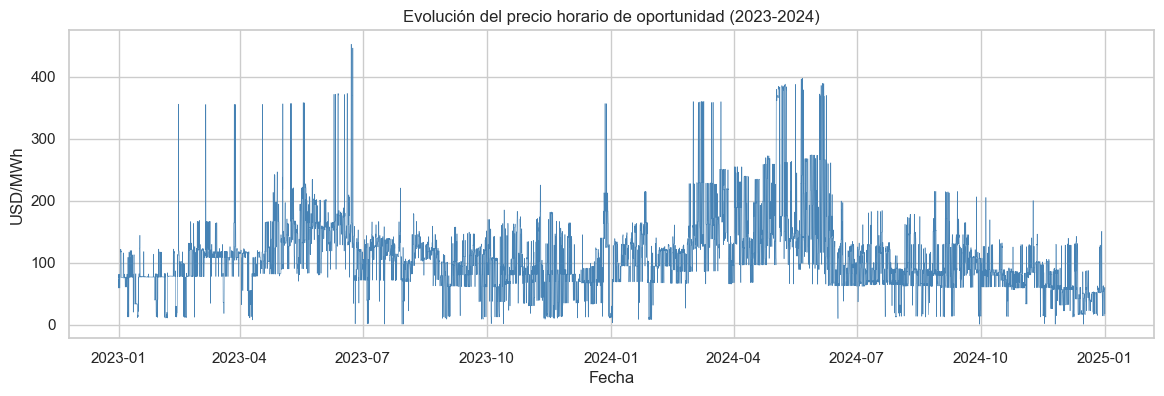

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["datetime"], train["usd_mwh"], lw=0.4, color="steelblue")
ax.set(title="Evolución del precio horario de oportunidad (2023-2024)", xlabel="Fecha", ylabel="USD/MWh")
savefig(fig, "01_evolucion_precio.png"); plt.show()

### 2.2 Precio promedio por hora, día de la semana y mes

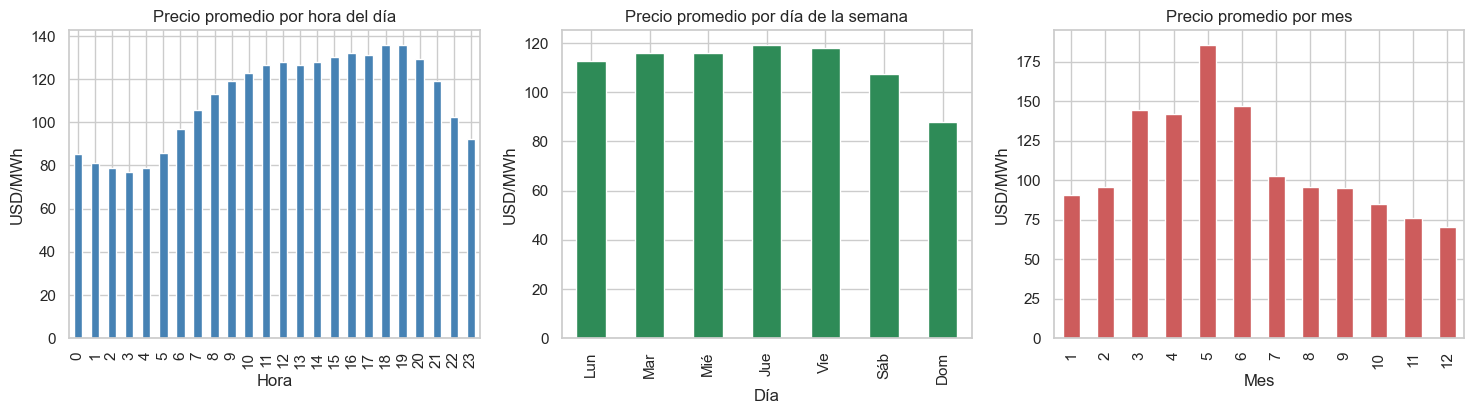

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
eda.groupby("hour")["usd_mwh"].mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set(title="Precio promedio por hora del día", xlabel="Hora", ylabel="USD/MWh")
g = eda.groupby("dayofweek")["usd_mwh"].mean(); g.index = DOW
g.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set(title="Precio promedio por día de la semana", xlabel="Día", ylabel="USD/MWh")
eda.groupby("month")["usd_mwh"].mean().plot(kind="bar", ax=axes[2], color="indianred")
axes[2].set(title="Precio promedio por mes", xlabel="Mes", ylabel="USD/MWh")
savefig(fig, "02_promedios_temporales.png"); plt.show()

### 2.3 Comparación entre 2023 y 2024

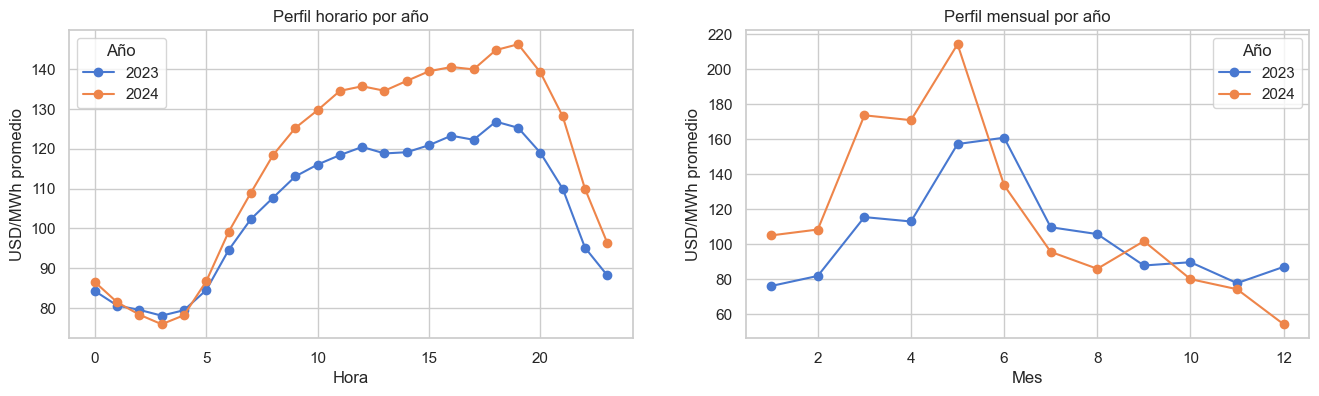

       mean  median   std  min    max
year                                 
2023  105.3   104.9  51.8  0.9  452.6
2024  116.5    96.4  69.6  0.6  397.5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for year, sub in eda.groupby("year"):
    sub.groupby("hour")["usd_mwh"].mean().plot(ax=axes[0], marker="o", label=str(year))
    sub.groupby("month")["usd_mwh"].mean().plot(ax=axes[1], marker="o", label=str(year))
axes[0].set(title="Perfil horario por año", xlabel="Hora", ylabel="USD/MWh promedio"); axes[0].legend(title="Año")
axes[1].set(title="Perfil mensual por año", xlabel="Mes", ylabel="USD/MWh promedio"); axes[1].legend(title="Año")
savefig(fig, "03_comparacion_anios.png"); plt.show()

print(eda.groupby("year")["usd_mwh"].agg(["mean", "median", "std", "min", "max"]).round(1))

### 2.4 Distribución del precio y valores extremos

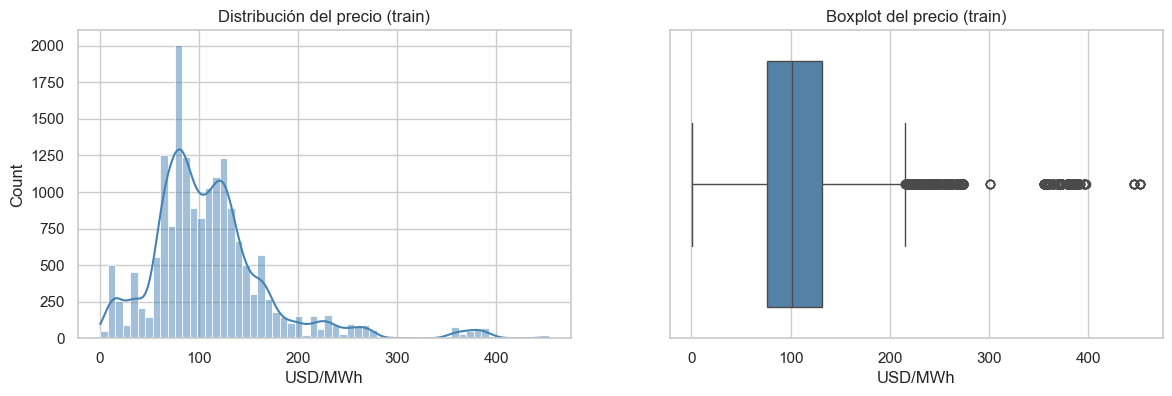

count    17534.00
mean       110.91
std         61.61
min          0.63
50%        101.54
90%        172.72
95%        228.32
99%        372.73
max        452.59
Name: usd_mwh, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train["usd_mwh"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set(title="Distribución del precio (train)", xlabel="USD/MWh")
sns.boxplot(x=train["usd_mwh"], ax=axes[1], color="steelblue")
axes[1].set(title="Boxplot del precio (train)", xlabel="USD/MWh")
savefig(fig, "04_distribucion.png"); plt.show()

print(train["usd_mwh"].describe(percentiles=[.5, .9, .95, .99]).round(2))

### 2.5 Heatmap: hora del día × día de la semana

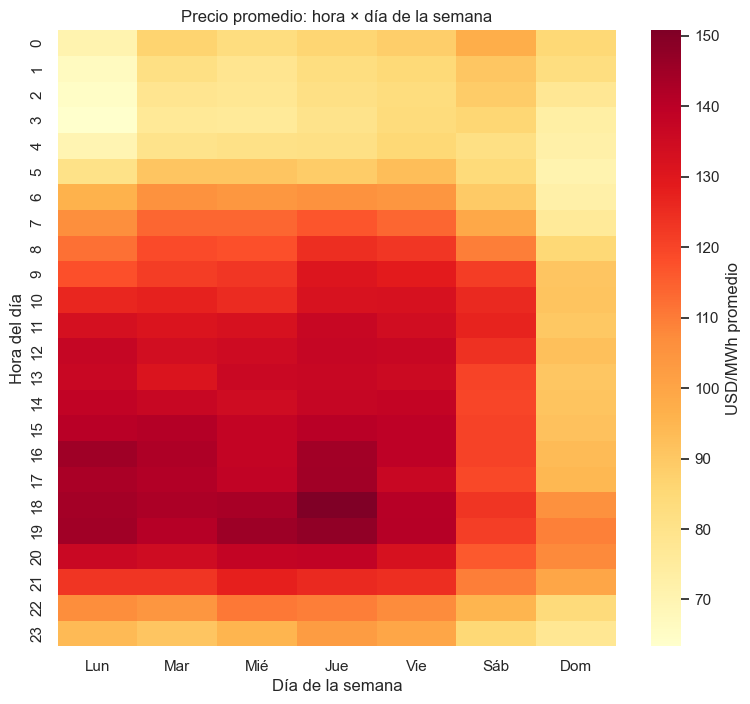

In [14]:
pivot = eda.pivot_table(index="hour", columns="dayofweek", values="usd_mwh", aggfunc="mean")
pivot.columns = DOW
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "USD/MWh promedio"})
ax.set(title="Precio promedio: hora × día de la semana", xlabel="Día de la semana", ylabel="Hora del día")
savefig(fig, "05_heatmap.png"); plt.show()

## 3. Ingeniería de Variables

Construimos predictores en tres grupos:

1. **Calendario** (`add_calendar_features`): hora, día de la semana, mes, trimestre, fin de semana,
   estación seca, etc
2. **Cíclicas** (`add_cyclic_features`): seno/coseno de hora, mes y día de la semana, para que el modelo sepa que la hora 0 viene después de la 23
3. **Medias históricas del precio** (`fit_historical_means` + `add_historical_means`): media del
   precio por hora, por mes, por día de la semana y por hora×día. Usan la variable objetivo, así
   que se calculan con una función solo sobre el train (2023–2024) y se agregan como columnas
   `histmean_*`; al aplicarlas a 2025 nunca se usa información de ese año.

Además clasificamos las horas valle/intermedia/pico (`classify_hours`) usando solo el train.


In [15]:
def add_cyclic_features(df):
    """Codifica variables periódicas con seno/coseno para preservar su continuidad."""
    out = df.copy()
    out["hour_sin"] = np.sin(2*np.pi*out["hour"]/24);   out["hour_cos"] = np.cos(2*np.pi*out["hour"]/24)
    out["month_sin"] = np.sin(2*np.pi*out["month"]/12); out["month_cos"] = np.cos(2*np.pi*out["month"]/12)
    out["dow_sin"] = np.sin(2*np.pi*out["dayofweek"]/7); out["dow_cos"] = np.cos(2*np.pi*out["dayofweek"]/7)
    return out

def build_feature_frame(df):
    """Aplica calendario + cíclicas. Punto de entrada para construir los predictores."""
    return add_cyclic_features(add_calendar_features(df))


HIST_GROUP_KEYS = [["hour"], ["month"], ["dayofweek"], ["hour", "dayofweek"]]

def fit_historical_means(train_df, group_keys=HIST_GROUP_KEYS, target="usd_mwh"):
    """Calcula la media del precio por grupo usando SOLO el train (sin fuga hacia 2025).

    Devuelve un dict con las medias por cada agrupamiento (hora, mes, día de semana, hora×día)
    y la media global como respaldo para grupos no vistos.
    """
    train_df = train_df.dropna(subset=[target])
    maps = {"__".join(keys): train_df.groupby(keys)[target].mean() for keys in group_keys}
    return {"maps": maps, "global_mean": float(train_df[target].mean()), "group_keys": group_keys}

def add_historical_means(df, hist):
    """Agrega columnas histmean_* mapeando las medias del train (respaldo: media global)."""
    out = df.copy()
    for keys in hist["group_keys"]:
        name = "histmean_" + "__".join(keys)
        means = hist["maps"]["__".join(keys)]
        if len(keys) == 1:
            mapped = out[keys[0]].map(means)
        else:
            idx = pd.MultiIndex.from_frame(out[keys])
            mapped = pd.Series(means.reindex(idx).values, index=out.index)
        out[name] = mapped.fillna(hist["global_mean"])
    return out

HISTMEAN = ["histmean_" + "__".join(k) for k in HIST_GROUP_KEYS]


def classify_hours(train_df, price_col="usd_mwh", low_q=1/3, high_q=2/3):
    """Clasifica horas en valle/intermedia/pico por terciles del precio medio (Req. 7.3, solo train)."""
    hourly = train_df.dropna(subset=[price_col]).groupby("hour")[price_col].mean()
    lo, hi = hourly.quantile(low_q), hourly.quantile(high_q)
    label = lambda v: "valle" if v <= lo else ("pico" if v >= hi else "intermedia")
    return {h: label(v) for h, v in hourly.items()}, hourly

### 3.1 Construcción de las matrices de features

In [16]:
# 1) Calendario + cíclicas (no usan el precio)
X_train = build_feature_frame(train)
X_hold = build_feature_frame(holdout)

# 2) Medias históricas: se AJUSTAN solo con el train y se aplican a ambos conjuntos
hist = fit_historical_means(X_train)
X_train = add_historical_means(X_train, hist)
X_hold = add_historical_means(X_hold, hist)

y_train = X_train["usd_mwh"].values
y_hold = X_hold["usd_mwh"].values

feature_cols = [c for c in X_train.columns if c not in ("datetime", "date", "year", "usd_mwh", "is_price_error")]
print("Predictores construidos:")
print(feature_cols)

# Verificación de las medias históricas agregadas como columnas
display(X_train[HISTMEAN].head(3).round(2))

Predictores construidos:
['hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear', 'is_weekend', 'is_dry_season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'histmean_hour', 'histmean_month', 'histmean_dayofweek', 'histmean_hour__dayofweek']


,histmean_hour,histmean_month,histmean_dayofweek,histmean_hour__dayofweek
0,85.38,90.54,87.77,85.30
1,81.03,90.54,87.77,82.73
2,78.91,90.54,87.77,77.66


### 3.2 Clasificación de horas valle / intermedia / pico

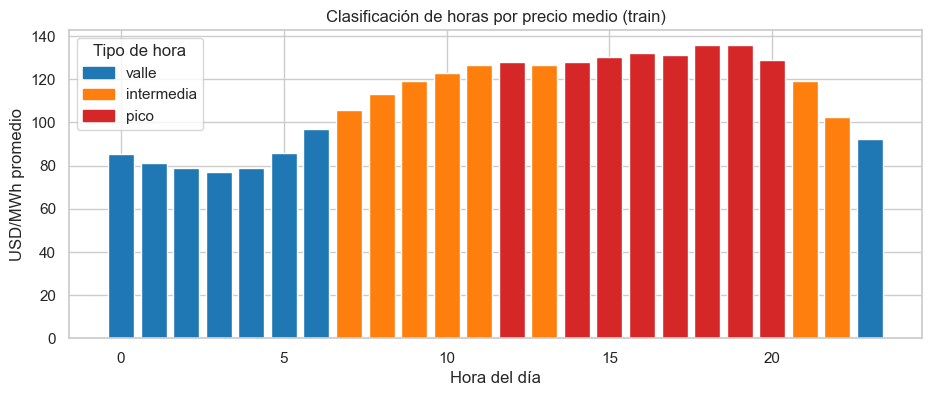

tipo
intermedia       [7, 8, 9, 10, 11, 13, 21, 22]
pico          [12, 14, 15, 16, 17, 18, 19, 20]
valle                [0, 1, 2, 3, 4, 5, 6, 23]
Name: hora, dtype: object

In [17]:
hour_class, hourly_mean = classify_hours(train)
colors = {"valle": "tab:blue", "intermedia": "tab:orange", "pico": "tab:red"}
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_mean.index, hourly_mean.values, color=[colors[hour_class[h]] for h in hourly_mean.index])
ax.set(title="Clasificación de horas por precio medio (train)", xlabel="Hora del día", ylabel="USD/MWh promedio")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="Tipo de hora")
savefig(fig, "06_clasificacion_horas.png"); plt.show()

pd.Series(hour_class).rename("tipo").rename_axis("hora").reset_index().groupby("tipo")["hora"].apply(list)

## 4. Preprocesamiento y Modelado

Todo el preprocesamiento vive dentro de `Pipeline` + `ColumnTransformer`, de modo que se ajusta solo
con el train de cada fold (sin leakage). Definimos dos esquemas de columnas:

- **`make_full_preprocessor`** (modelos lineales/regularizados): columnas `histmean_*`
  escaladas + *one-hot* de variables categóricas temporales + cíclicas escaladas + indicadores binarios.
- **`make_numeric_preprocessor`** (modelos polinomiales): completamente numéricas


In [21]:
CATEGORICAL = ["hour", "dayofweek", "month", "quarter"]
CYCLIC = ["hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos"]
NUMERIC = ["hour", "dayofweek", "month", "day", "dayofyear", "weekofyear"]
BINARY = ["is_weekend", "is_dry_season"]
# HISTMEAN se definió en la sección 3 (columnas histmean_* ya calculadas con el train)

def make_full_preprocessor():
    """Preprocesador con one-hot, para modelos lineales/regularizados y ensembles."""
    return ColumnTransformer([
        ("histmean", StandardScaler(), HISTMEAN),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("cyc", StandardScaler(), CYCLIC),
        ("bin", "passthrough", BINARY),
    ], remainder="drop")

def make_numeric_preprocessor():
    """Preprocesador 100% numérico, apto para PolynomialFeatures."""
    return ColumnTransformer([
        ("histmean", StandardScaler(), HISTMEAN),
        ("cyc", StandardScaler(), CYCLIC),
        ("num", StandardScaler(), NUMERIC),
        ("bin", "passthrough", BINARY),
    ], remainder="drop")

def build_model_set():
    """Devuelve {nombre: (pipeline, param_grid, randomized)} con distintos niveles de complejidad."""
    alphas = np.logspace(-3, 3, 13)
    model_set = {}
    model_set["baseline_mean"] = (Pipeline([("model", DummyRegressor(strategy="mean"))]), {}, False)
    model_set["linear"] = (Pipeline([("prep", make_full_preprocessor()), ("model", LinearRegression())]), {}, False)
    model_set["ridge"] = (Pipeline([("prep", make_full_preprocessor()), ("model", Ridge())]),
                    {"model__alpha": alphas}, False)
    model_set["lasso"] = (Pipeline([("prep", make_full_preprocessor()), ("model", Lasso(max_iter=50000))]),
                    {"model__alpha": np.logspace(-3, 1, 9)}, False)
    model_set["elasticnet"] = (Pipeline([("prep", make_full_preprocessor()), ("model", ElasticNet(max_iter=50000))]),
                         {"model__alpha": np.logspace(-3, 1, 7), "model__l1_ratio": [0.1, 0.5, 0.9]}, False)
    model_set["polynomial"] = (Pipeline([("prep", make_numeric_preprocessor()),
                                   ("poly", PolynomialFeatures(include_bias=False)),
                                   ("model", LinearRegression())]), {"poly__degree": [2, 3]}, False)
    model_set["poly_ridge"] = (Pipeline([("prep", make_numeric_preprocessor()),
                                   ("poly", PolynomialFeatures(include_bias=False)),
                                   ("model", Ridge())]),
                         {"poly__degree": [2, 3], "model__alpha": alphas}, False)
    model_set["random_forest"] = (Pipeline([("prep", make_full_preprocessor()),
                                      ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
                            {"model__n_estimators": [200, 300], "model__max_depth": [None, 12, 20],
                             "model__min_samples_leaf": [1, 5]}, True)
    model_set["gradient_boosting"] = (Pipeline([("prep", make_full_preprocessor()),
                                          ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
                                {"model__n_estimators": [200, 400], "model__max_depth": [2, 3],
                                 "model__learning_rate": [0.05, 0.1]}, True)
    return model_set

model_set = build_model_set()
print("Modelos en el model_set:", list(model_set.keys()))

Modelos en el model_set: ['baseline_mean', 'linear', 'ridge', 'lasso', 'elasticnet', 'polynomial', 'poly_ridge', 'random_forest', 'gradient_boosting']


## 5. Optimización y Comparación de Modelos

Se optimizan los hiperparámetros con validación cruzada que respeta el orden temporal
(`TimeSeriesSplit`): cada fold entrena con el pasado y valida con el futuro inmediato, evitando
filtrar información futura

In [25]:
def regression_metrics(y_true, y_pred):
    """MAE, RMSE, R2 y MAPE"""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true > 1.0
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "MAPE": float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100) if mask.any() else np.nan,
    }

def time_series_search(pipeline, grid, X, y, randomized=False, n_splits=5, n_iter=10):
    """Ajusta hiperparámetros con TimeSeriesSplit (GridSearch o RandomizedSearch)."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scoring = "neg_root_mean_squared_error"
    if not grid:
        score = float(np.mean(cross_val_score(pipeline, X, y, cv=tscv, scoring=scoring)))
        pipeline.fit(X, y)
        return pipeline, {"best_params": {}, "best_cv_rmse": -score}
    Search = RandomizedSearchCV if randomized else GridSearchCV
    kw = dict(estimator=pipeline, cv=tscv, scoring=scoring, n_jobs=-1)
    kw.update(dict(param_distributions=grid, n_iter=n_iter, random_state=RANDOM_STATE) if randomized
              else dict(param_grid=grid))
    s = Search(**kw).fit(X, y)
    return s.best_estimator_, {"best_params": s.best_params_, "best_cv_rmse": -s.best_score_}

### 5.1 Entrenamiento y tabla comparativa

Se entrena cada modelo con cross validation temporal sobre 2023–2024 y se reporta tanto el RMSE de validación
cruzada como las métricas sobre el holdout 2025.

In [26]:
results, fitted = [], {}
for name, (pipe, grid, randomized) in model_set.items():
    best, info = time_series_search(pipe, grid, X_train, y_train, randomized=randomized, n_iter=8)
    fitted[name] = best
    pred = best.predict(X_hold)
    row = {"modelo": name, "RMSE_CV": info["best_cv_rmse"]}
    row.update({f"{k}_2025": v for k, v in regression_metrics(y_hold, pred).items()})
    row["hiperparámetros"] = str(info["best_params"])
    results.append(row)
    print(f"  ✓ {name}")

comparison = pd.DataFrame(results).sort_values("RMSE_CV").reset_index(drop=True)
comparison.round(3)

  ✓ baseline_mean
  ✓ linear
  ✓ ridge
  ✓ lasso
  ✓ elasticnet
  ✓ polynomial
  ✓ poly_ridge
  ✓ random_forest
  ✓ gradient_boosting


,modelo,RMSE_CV,MAE_2025,RMSE_2025,R2_2025,MAPE_2025,hiperparámetros
0,lasso,49.876,35.846,44.453,-0.448,121.524,{'model__alpha': np.float64(3.1622776601683795)}
1,elasticnet,50.823,35.452,43.407,-0.381,122.713,{'model__alpha': np.float64(2.154434690031882)...
2,ridge,52.039,36.872,45.751,-0.534,121.360,{'model__alpha': np.float64(1000.0)}
3,gradient_boosting,53.066,36.368,46.192,-0.564,119.064,"{'model__n_estimators': 200, 'model__max_depth..."
4,random_forest,54.137,37.040,47.410,-0.647,118.858,"{'model__n_estimators': 200, 'model__min_sampl..."
5,linear,56.721,37.115,46.263,-0.569,120.326,{}
6,baseline_mean,66.042,37.469,45.349,-0.507,143.989,{}
7,poly_ridge,79.323,36.954,46.510,-0.585,118.914,"{'model__alpha': np.float64(1000.0), 'poly__de..."
8,polynomial,35285.464,132.796,213.515,-32.411,343.542,{'poly__degree': 2}


### 5.2 Selección del modelo ganador

El modelo se elige por menor RMSE de validación cruzada

In [55]:
best_name = comparison.iloc[0]["modelo"]
print(f"Modelo ganador (por RMSE_CV): {best_name}")
comparison.iloc[[0]].round(3)

Modelo ganador (por RMSE_CV): lasso


,modelo,RMSE_CV,MAE_2025,RMSE_2025,R2_2025,MAPE_2025,hiperparámetros
0,lasso,49.876,35.846,44.453,-0.448,121.524,{'model__alpha': np.float64(3.1622776601683795)}


### 5.3 Curva de validación (sesgo vs varianza)

Para el **modelo ganador (Lasso)**, graficamos el error de train y de CV frente a `alpha`. Esto permite
discutir subajuste/sobreajuste y justificar el valor de `alpha` elegido por la búsqueda. Con `alpha` muy
bajo el modelo sobreajusta; con `alpha` muy alto Lasso anula los coeficientes y subajusta (predice casi
la media). El mínimo de la curva de validación marca el mejor equilibrio.

In [ ]:
alphas = np.logspace(-3, 3, 13)
tscv = TimeSeriesSplit(n_splits=5)
tr_sc, va_sc = validation_curve(
    Pipeline([("prep", make_full_preprocessor()), ("model", Lasso(max_iter=50000))]),
    X_train, y_train, param_name="model__alpha", param_range=alphas,
    cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, -tr_sc.mean(1), marker="o", label="Entrenamiento")
ax.plot(alphas, -va_sc.mean(1), marker="s", label="Validación (CV)")
best_alpha = alphas[np.argmin(-va_sc.mean(1))]
ax.axvline(best_alpha, color="gray", ls="--", lw=1, label=f"mejor alpha ~ {best_alpha:.2g}")
ax.set_xscale("log"); ax.set(title="Curva de validación — Lasso (modelo ganador)", xlabel="alpha (regularización)", ylabel="RMSE")
ax.legend(); savefig(fig, "07_curva_validacion.png"); plt.show()

## 6. Evaluación Final sobre 2025

Se reentrena todo 2023–2024 y se predice 2025. Como el archivo de 2025
contiene los precios reales, evaluamos el desempeño y exportamos el archivo de predicciones.

In [57]:
best_model = fitted[best_name]
best_model.fit(X_train, y_train)            
y_pred_2025 = best_model.predict(X_hold)

final_metrics = regression_metrics(y_hold, y_pred_2025)
print(f"Desempeño del modelo '{best_name}' sobre 2025:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.3f}")

Desempeño del modelo 'lasso' sobre 2025:
  MAE: 35.846
  RMSE: 44.453
  R2: -0.448
  MAPE: 121.524


### 6.1 Precio real vs predicho y residuos

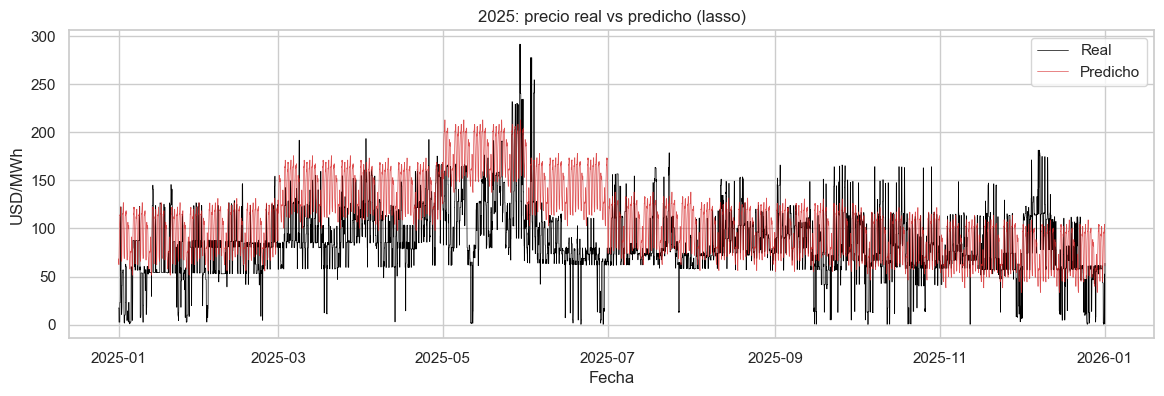

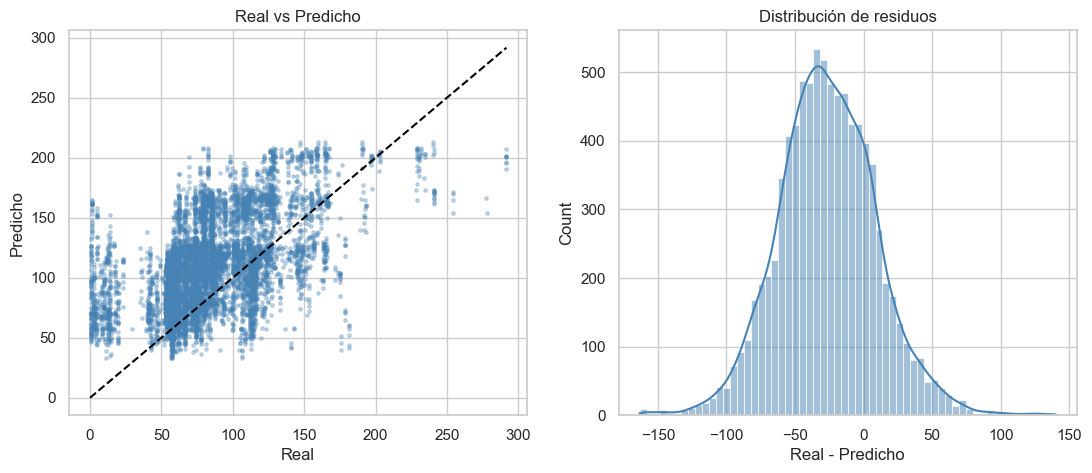

In [58]:
eval_df = X_hold[["datetime", "hour", "month", "dayofweek"]].copy()
eval_df["y_real"] = y_hold
eval_df["y_pred"] = y_pred_2025
eval_df["residuo"] = eval_df["y_real"] - eval_df["y_pred"]
eval_df["abs_error"] = eval_df["residuo"].abs()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eval_df["datetime"], eval_df["y_real"], lw=0.5, color="black", label="Real")
ax.plot(eval_df["datetime"], eval_df["y_pred"], lw=0.5, color="tab:red", alpha=0.8, label="Predicho")
ax.set(title=f"2025: precio real vs predicho ({best_name})", xlabel="Fecha", ylabel="USD/MWh"); ax.legend()
savefig(fig, "08_real_vs_pred_serie.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(eval_df["y_real"], eval_df["y_pred"], s=6, alpha=0.3, color="steelblue")
lims = [0, max(eval_df["y_real"].max(), eval_df["y_pred"].max())]
axes[0].plot(lims, lims, "--", color="black"); axes[0].set(title="Real vs Predicho", xlabel="Real", ylabel="Predicho")
sns.histplot(eval_df["residuo"], bins=60, kde=True, ax=axes[1], color="steelblue")
axes[1].set(title="Distribución de residuos", xlabel="Real - Predicho")
savefig(fig, "09_scatter_residuos.png"); plt.show()

### 6.2 Error promedio por hora, mes y día de la semana

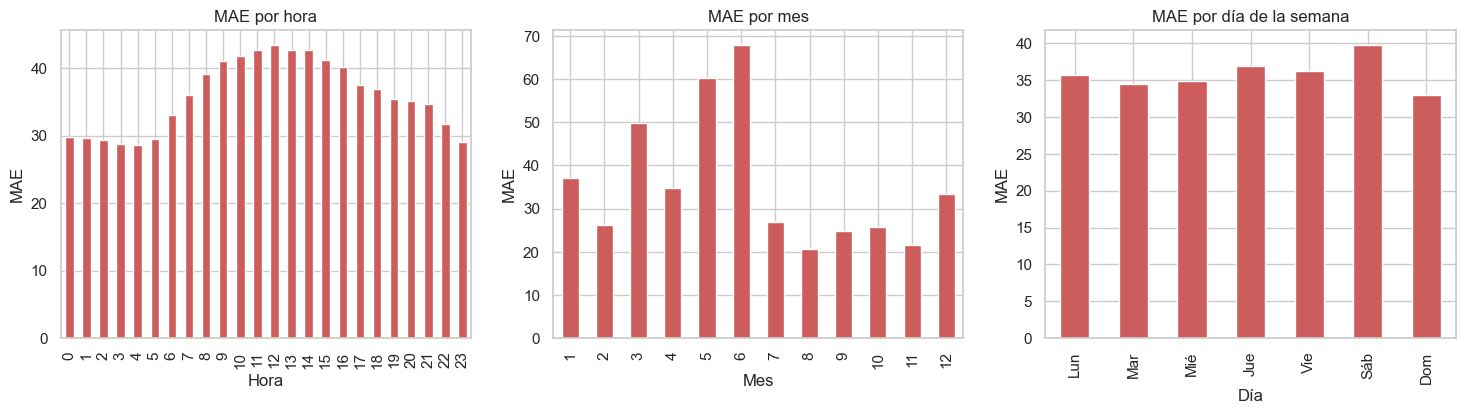

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
eval_df.groupby("hour")["abs_error"].mean().plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set(title="MAE por hora", xlabel="Hora", ylabel="MAE")
eval_df.groupby("month")["abs_error"].mean().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set(title="MAE por mes", xlabel="Mes", ylabel="MAE")
g = eval_df.groupby("dayofweek")["abs_error"].mean(); g.index = DOW
g.plot(kind="bar", ax=axes[2], color="indianred"); axes[2].set(title="MAE por día de la semana", xlabel="Día", ylabel="MAE")
savefig(fig, "10_error_por_periodo.png"); plt.show()

### 6.3 Exportación del archivo de predicciones

In [60]:
predicciones = pd.DataFrame({
    "fecha": eval_df["datetime"].dt.date,
    "hora": eval_df["hour"],
    "precio_predicho": eval_df["y_pred"].round(4),
    "precio_real": eval_df["y_real"].round(4),
    "error_absoluto": eval_df["abs_error"].round(4),
})
predicciones.to_csv("outputs/predicciones_2025.csv", index=False)
print(f"Guardado outputs/predicciones_2025.csv con {len(predicciones):,} filas")
predicciones.head()

Guardado outputs/predicciones_2025.csv con 8,758 filas


,fecha,hora,precio_predicho,precio_real,error_absoluto
0,2025-01-01,0,68.4039,17.3103,51.0936
1,2025-01-01,1,64.4862,17.3103,47.1759
2,2025-01-01,2,64.0696,17.3103,46.7593
3,2025-01-01,3,62.3478,17.3103,45.0375
4,2025-01-01,4,66.6959,2.5689,64.1270


## 7. Explicabilidad, Preguntas Obligatorias y Conclusión

### 7.0 Importancia de variables
Combinamos la importancia del mejor ensemble con la permutation importance, que mide
cuánto empeora el error al permutar cada predictor 

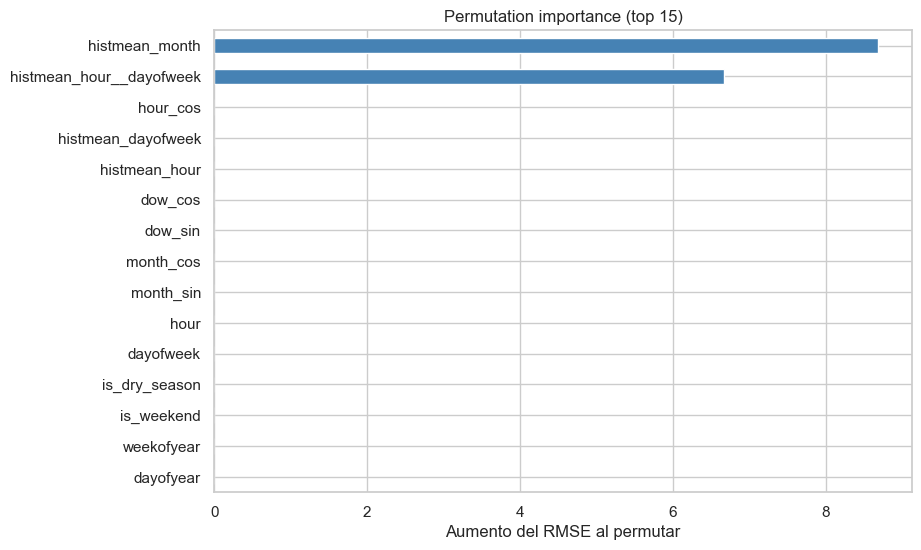

histmean_month              8.688
histmean_hour__dayofweek    6.661
hour_cos                    0.000
histmean_dayofweek          0.000
histmean_hour               0.000
dow_cos                     0.000
dow_sin                     0.000
month_cos                   0.000
month_sin                   0.000
hour                        0.000
dayofweek                   0.000
is_dry_season               0.000
is_weekend                  0.000
weekofyear                  0.000
dayofyear                   0.000
dtype: float64

In [61]:
# Permutation importance sobre el holdout
# Se pasan solo las columnas de features
perm = permutation_importance(best_model, X_hold[feature_cols], y_hold, n_repeats=5,
                              random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
imp[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set(title="Permutation importance (top 15)", xlabel="Aumento del RMSE al permutar")
savefig(fig, "11_importancia_variables.png"); plt.show()
imp.round(3)

### Respuestas a las preguntas obligatorias

> Las respuestas combinan la evidencia de las secciones anteriores. Algunos valores numéricos
> (medias, métricas) se imprimen abajo para respaldarlas.

In [62]:
print("Resumen de evidencia para las preguntas:")
print(f"  Precio medio 2023: {data[2023].usd_mwh.mean():.1f} | 2024: {data[2024].usd_mwh.mean():.1f} | 2025: {data[2025].usd_mwh.mean():.1f} USD/MWh")
print(f"  Hora más cara (train): {hourly_mean.idxmax()}h ({hourly_mean.max():.1f}) | más barata: {hourly_mean.idxmin()}h ({hourly_mean.min():.1f})")
print(f"  Modelo ganador: {best_name} | RMSE 2025: {final_metrics['RMSE']:.1f} | MAE: {final_metrics['MAE']:.1f} | R2: {final_metrics['R2']:.3f}")
print(f"  RMSE baseline (media) 2025: {comparison.set_index('modelo').loc['baseline_mean','RMSE_2025']:.1f}")

Resumen de evidencia para las preguntas:
  Precio medio 2023: 105.3 | 2024: 116.5 | 2025: 84.6 USD/MWh
  Hora más cara (train): 18h (135.9) | más barata: 3h (77.0)
  Modelo ganador: lasso | RMSE 2025: 44.5 | MAE: 35.8 | R2: -0.448
  RMSE baseline (media) 2025: 45.3


**7.1 ¿Cuál es el comportamiento general del precio durante 2023 y 2024?**
El precio horario es **volátil** y de distribución **sesgada a la derecha**, con la mayoría de horas
entre ~50 y ~200 USD/MWh y picos puntuales por escasez. Los promedios anuales son **similares**
(~105 en 2023 y ~116 en 2024 USD/MWh; medianas ~105 y ~96), pero 2024 es más volátil (mayor
desviación y cola alta). (Ver §2.1, §2.4 y la tabla por año en §2.3.)

**7.2 ¿Qué patrones horarios se observan?**
Hay un **perfil diario claro** (§2.2, §2.5): precios bajos de madrugada (00–06 h), una rampa matutina
y los valores más altos entre el mediodía y la noche temprana, asociados a la mayor demanda.

**7.3 ¿Existen horas pico, intermedias y valle? ¿Cómo las definieron?**
Sí. Se definieron por **terciles del precio medio por hora en el train** (§3.2): **valle** las horas
del tercil inferior (madrugada), **pico** las del superior (mediodía–tarde) e **intermedia** el resto.

**7.4 ¿El precio se influye más por la hora, el día de la semana o el mes?**
La **hora** es el factor dominante (mayor variación del precio medio y mayor importancia en §7.0),
seguida del **mes** (estacionalidad hidrológica). El **día de la semana** influye poco (§2.2, §2.5).

**7.5 ¿Qué tan estable es el comportamiento entre 2023 y 2024?**
La **forma** (perfil horario y estacional) es razonablemente estable y los **niveles** anuales son
parecidos (~105 vs ~116), aunque cambia la volatilidad (§2.3). Sin embargo, la relación
calendario→precio **no se traslada bien a 2025**: ese año es algo más bajo (~85) y mucho menos
volátil (desv. ~37 vs ~52–70), lo que basta para que los patrones aprendidos pierdan poder predictivo.

**7.6 ¿Qué eventos o comportamientos atípicos se observan?**
Picos de precio aislados (escasez/restricciones) y, sobre todo, errores de captura: horas mal
digitadas y precios imposibles (hasta 1.3 M USD/MWh), corregidos en §1.

**7.7 ¿Los valores extremos deben eliminarse, transformarse o conservarse?**
Se distingue: (a) los **errores de digitación** (>1000 USD/MWh y textos corruptos) son irrecuperables
y se marcan como faltantes/descartan; (b) los **picos altos plausibles** (~300–450 USD/MWh) son
información real de mercado y se **conservan**. Eliminarlos sesgaría el modelo ante escasez real.

**7.8 ¿Qué variables ayudaron más a reducir el error?**
Las **medias históricas por hora** y **hora×día de la semana**, junto con las variables **horarias**
(one-hot/cíclicas). El mes aporta estacionalidad. (Ver §7.0.)

**7.9 ¿Qué tan difícil es predecir el precio solo con calendario e histórico?**
**Muy difícil.** Sobre 2025 los modelos apenas mejoran al baseline ingenuo y el **R² sigue negativo**
(peor que predecir el promedio del propio 2025): los predictores de calendario explican poco de la
varianza horaria. El error absoluto medio (~36 USD/MWh) equivale a ~43 % del precio medio. La causa es
que el precio lo determinan factores ausentes del calendario (combustibles, hidrología, demanda, disponibilidad).

**7.10 ¿Confiaría en este modelo como parte del AMM?**
**No para decisiones operativas.** Aunque mejora levemente a un predictor ingenuo, su R² negativo en
datos no vistos muestra que no captura el nivel real de 2025; solo es útil como **referencia
cualitativa** del patrón horario relativo (qué horas tienden a ser caras o baratas). Para decisiones
reales haría falta incorporar variables de mercado y reentrenar con datos recientes.

**7.11 ¿Qué información adicional mejoraría el modelo?**
**Demanda** horaria, **generación por tecnología**, **hidrología** (embalses, caudales), **precios de
combustibles**, **indisponibilidad de plantas**, **importaciones/exportaciones** y **restricciones de
transmisión**. Estas variables explican la formación del precio que el calendario no puede capturar.

### Conclusión

- **Modelo seleccionado:** el de menor RMSE en validación cruzada temporal (ver §5.2), con sus
  hiperparámetros óptimos reportados en la tabla comparativa. Resultó de la familia lineal regularizada,
  cuyo desempeño en CV es prácticamente igual al de los ensembles, pero con un modelo más simple e
  interpretable (principio de parsimonia).
- **Variables más relevantes:** medias históricas por hora y hora×día de la semana, y las variables
  horarias; la estacionalidad mensual aporta de forma secundaria (§7.0).
- **Desempeño 2025:** el modelo reproduce el **perfil** horario/estacional, pero en datos no vistos
  **no supera de manera significativa a un predictor ingenuo** (R² negativo, MAE ~37 USD/MWh). El
  poder predictivo del calendario sobre el precio horario es limitado.
- **Predice mejor** en horas/meses de comportamiento estable y cercano al histórico; **peor** en
  periodos atípicos y cuando la volatilidad de 2025 difiere de la de 2023–2024.
- **Bias-variance:** la comparación evidenció que el **polinomio puro sobreajusta** (error de CV
  enorme) mientras que su versión **regularizada** lo controla (§5.1, §5.3) — ejemplo directo del
  compromiso sesgo–varianza.
- **Limitaciones:** solo usa señales de calendario/histórico; no observa los fundamentales del mercado
  (demanda, hidrología, combustibles), que son los que forman el precio.
- **Mejoras:** incorporar variables exógenas (§7.11), reentrenamiento frecuente y, eventualmente,
  modelos específicos de series temporales con regresores externos.